# From Neural Networks to Recurrent Neural Networks

In this notebook, we will build an understanding of why traditional neural networks are not sufficient for sequential data, and how this leads to the development of Recurrent Neural Networks (RNNs).

## 1. Limitation of Traditional Neural Networks

Traditional neural networks (feedforward neural networks) assume that all input features are independent of each other.

A standard neural network can be written as:

y = f(Wx + b)

Where:
- x is the input
- W is the weight matrix
- b is the bias
- f is an activation function

This formulation assumes:
- Each input is processed independently
- There is no notion of order or time

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20231107165249/linear.png" width="800" height="400">


### Why This Becomes a Problem

Many real-world data sources are sequential, meaning the order of data matters.

Example:

"I love you"  
"You love I"

Both sentences contain the same words, but their meanings are completely different due to the order.

A traditional neural network cannot capture this difference effectively.

### Key Insight

In many applications:

- The current input depends on previous inputs
- The model needs some form of memory

Examples:
- Language modeling
- Time series prediction
- Network traffic analysis

This motivates the need for models that can retain past information.

## 2. Understanding Sequence Data

Sequence data is a type of data where the order of elements is important.

A sequence can be represented as:

x₁, x₂, x₃, ..., xₜ

Where:
- xₜ represents the value at time step t
- T is the sequence length

### Characteristics of Sequence Data

1. Order matters  
2. Elements depend on previous elements  
3. Sequence length can vary  

This makes sequence data fundamentally different from traditional tabular data.

### Types of Sequence Data

- Time Series Data (stock prices, temperature)
- Text Data (sentences, documents)
- Signal Data (audio, ECG)
- Network Data (packet flows, logs)

## 3. Exploring Sequence Data with a Simple Example

Let us consider a simple numerical sequence:

1, 2, 3, 4, 5, 6, 7

This sequence follows a pattern:

xₜ = xₜ₋₁ + 1

Each value depends on the previous value.

In [113]:
import numpy as np

sequence = np.array([1, 2, 3, 4, 5, 6, 7, 8])
sequence

array([1, 2, 3, 4, 5, 6, 7, 8])

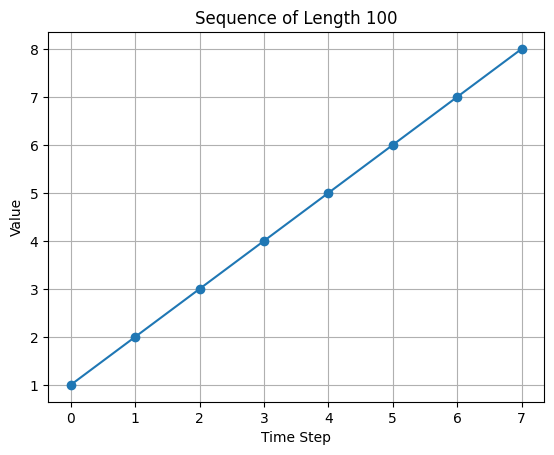

In [114]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(sequence, marker='o')
plt.title("Sequence of Length 100")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid()
plt.show()

### Converting Sequence into Training Data

We convert the sequence into input-output pairs using a sliding window.

Example:

Input: [1, 2, 3] → Output: 4  
Input: [2, 3, 4] → Output: 5

In [115]:
def create_sequence_data(seq, window_size):
    X = []
    y = []

    for i in range(len(seq) - window_size):
        X.append(seq[i:i+window_size])
        y.append(seq[i+window_size])

    return np.array(X), np.array(y)

X, y = create_sequence_data(sequence, window_size=3)

print("Input (X):")
print(X)

print("\nTarget (y):")
print(y)

Input (X):
[[1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]]

Target (y):
[4 5 6 7 8]


### Why This is Different

In traditional datasets:
- Each sample is independent

In sequence datasets:
- Samples overlap
- Order is preserved
- Previous values influence future values

### Visualization of Sequence Flow

We can think of the sequence like:

(1 → 2 → 3) → 4  
(2 → 3 → 4) → 5  

Each prediction depends on a chain of previous values.

This requires a model that can remember past information.

<img src="https://images.openai.com/static-rsc-4/c7YJ6P_w7Q9nXX348Q2Se2kSze7Eqq17MO0-Q9VBUf5b7anJmXFTUk9-vHvmBuGkffZz0MmmBwMWRZ5tJmeN_ozk_kuPlyUfdaaIWz0udR1MfdCenOG-zDtLNinXWXb3y7PaZKczAzr577dBS3jkFeGvCkQHHknZ9Jw1CWU7f9LCE4GUw4eAy8ExbvtIY50V?purpose=fullsize" width="600" height="200">

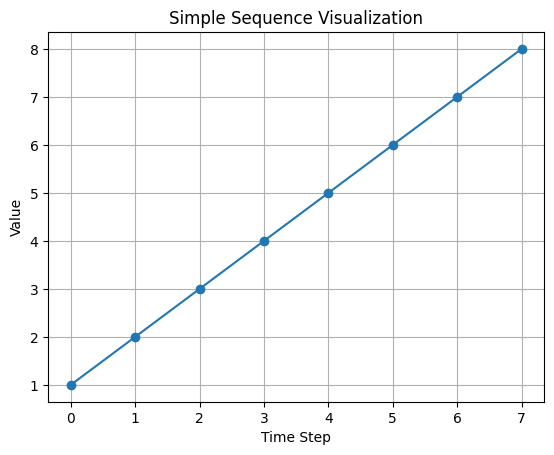

In [116]:
import matplotlib.pyplot as plt

plt.plot(sequence, marker='o')
plt.title("Simple Sequence Visualization")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid()
plt.show()

### Key Takeaways

- Sequence data depends on order
- Traditional neural networks do not capture temporal dependencies
- We need models that can retain memory of past inputs

This leads us to Recurrent Neural Networks (RNNs)

## 4. Why Traditional Neural Networks Fail for Sequence Data

Now that we understand sequence data, let us test whether a traditional neural network can learn such patterns.

We will try to use a simple feedforward neural network to predict the next value in a sequence.

### Conceptual Limitation

A traditional neural network processes inputs like this:

- Each input is independent
- No memory of previous inputs
- No temporal connection between data points

**Think:** If the model only sees [3, 4, 5] as static input, does it truly understand "sequence" or just numbers?




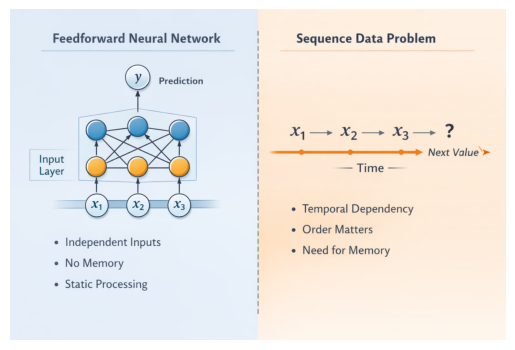

In [117]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('image1.png')
plt.imshow(img)
plt.axis('off') # Hide axes
plt.show()

In [118]:
import torch
import torch.nn as nn

# Using previous dataset
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

X_tensor, y_tensor

(tensor([[1., 2., 3.],
         [2., 3., 4.],
         [3., 4., 5.],
         [4., 5., 6.],
         [5., 6., 7.]]),
 tensor([[4.],
         [5.],
         [6.],
         [7.],
         [8.]]))

In [119]:
X_tensor.shape, y_tensor.shape

(torch.Size([5, 3]), torch.Size([5, 1]))

In [120]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(3, 1)  # input size = window size

    def forward(self, x):
        return self.fc(x)

model = SimpleNN()

In [121]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()

loss.item()

0.705047607421875

In [122]:
with torch.no_grad():
    predictions = model(X_tensor)

print("Predictions:")
print(predictions.squeeze().numpy())

print("\nActual:")
print(y)

Predictions:
[2.610691  4.1736803 5.7366705 7.29966   8.862649 ]

Actual:
[4 5 6 7 8]


### Observation

- The model may learn the pattern partially
- But it does not truly understand temporal dependency
- It treats input as static features

### Key Problem

The model does not have:
- Memory of previous states
- Ability to carry information across time

This is the fundamental limitation.

## 5. Introducing Recurrent Neural Networks (RNN)

To solve the limitation of traditional neural networks, we introduce a new idea:

A model that can remember previous information.

This is the core idea behind Recurrent Neural Networks.

### Key Idea

An RNN introduces a hidden state:

- It acts as memory
- It carries information from previous time steps

At each step:

hₜ = f(Wxₜ + Uhₜ₋₁)

Where:
- xₜ is current input
- hₜ₋₁ is previous memory
- hₜ is updated memory

<img src="https://cdn.jsdelivr.net/gh/AuthurWhywait/images/20211202152611.png" width="800" height="400">



### RNN Intuition

Instead of processing inputs independently, RNN processes them sequentially:

- Input comes step by step
- Memory is updated at each step
- Past influences the future

**Think:** What happens if we remove the hidden state? Does the model still remember anything?

### Unrolling the RNN

An RNN can be visualized as the same cell repeated over time:

x₁ → h₁  
x₂ → h₂  
x₃ → h₃  

Each step uses:
- Same weights
- Updated memory

This is called unrolling through time.

### Key Insights

- RNN introduces memory (hidden state)
- Information flows through time
- Same model is reused at each step

This makes RNN suitable for sequence data.

## 6. Preparing Data for RNN

Before implementing an RNN, we must understand how sequence data is structured for training.

RNNs do not take flat input like traditional neural networks.

They expect data in a sequential format.

### Input Shape for RNN

In PyTorch, RNN expects input in the following shape:

(batch_size, sequence_length, input_size)

Where:
- batch_size → number of samples
- sequence_length → number of time steps
- input_size → number of features per time step

### Understanding the Dimensions

Think of input like a 3D structure:

- Each sample contains a sequence
- Each sequence contains multiple time steps
- Each time step contains features

**Think:** What does each dimension represent in real-world data?

In [123]:
# Current shape
print("Original X shape:", X.shape)

# Convert to RNN format
X_rnn = X.reshape((X.shape[0], X.shape[1], 1))

print("RNN Input shape:", X_rnn.shape)

Original X shape: (5, 3)
RNN Input shape: (5, 3, 1)


In [124]:
X_rnn

array([[[1],
        [2],
        [3]],

       [[2],
        [3],
        [4]],

       [[3],
        [4],
        [5]],

       [[4],
        [5],
        [6]],

       [[5],
        [6],
        [7]]])

### Explanation

- We added a feature dimension (input_size = 1)
- Each number in the sequence is treated as a feature at each time step

Now the model can process data step-by-step instead of all at once.

In [125]:
X_rnn_tensor = torch.tensor(X_rnn, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

X_rnn_tensor.shape, y_tensor.shape

(torch.Size([5, 3, 1]), torch.Size([5]))

### Key Insight

The difference is not just shape — it is meaning:

- Traditional NN → sees data as static
- RNN → sees data as a sequence evolving over time

This is a conceptual shift, not just a technical change.

## 7. Implementing RNN from Scratch

Now we will build a simple RNN manually to understand how it works internally.

We will implement:
- Hidden state (memory)
- Sequential processing
- Weight sharing across time

### RNN Computation

At each time step:

hₜ = tanh(Wxₜ + Uhₜ₋₁)

yₜ = Vhₜ

Where:
- hₜ is hidden state (memory)
- xₜ is input at time t
- W, U, V are learnable weights

### Flow of Information

At each step:
- Input enters the network
- Previous memory is combined
- New memory is generated

**Think:** How does information persist across time steps?

In [126]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        # Size of the hidden state (this is the "memory" of the RNN)
        self.hidden_size = hidden_size

        # W: transforms current input x_t → hidden representation
        # Shape: (input_size → hidden_size)
        self.W = nn.Linear(input_size, hidden_size)

        # U: transforms previous hidden state h_{t-1} → new hidden contribution
        # Shape: (hidden_size → hidden_size)
        self.U = nn.Linear(hidden_size, hidden_size)

        # V: maps final hidden state → output
        # Shape: (hidden_size → output_size=1)
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        batch_size, seq_len, _ = x.size()

        # Initialize hidden state (memory) with zeros
        # Shape: (batch_size, hidden_size)
        # This represents h_0 (initial memory before seeing any input)
        h = torch.zeros(batch_size, self.hidden_size)

        # Process the sequence step-by-step (time dimension)
        for t in range(seq_len):

            # Extract input at time step t
            # Shape: (batch_size, input_size)
            x_t = x[:, t, :]

            # Core RNN update:
            # Combine current input and previous memory
            # h_t = tanh(Wx_t + Uh_{t-1})
            h = torch.tanh(
                self.W(x_t) +   # contribution from current input
                self.U(h)       # contribution from previous hidden state (memory)
            )

            # After this step:
            # h now contains updated memory incorporating x_t

        # After processing the full sequence,
        # h contains information from ALL time steps

        # Map final hidden state to output
        out = self.V(h)

        # Output shape: (batch_size, 1)
        return out

In [127]:
model_rnn = SimpleRNN(input_size=1, hidden_size=8)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.01)

In [128]:
for epoch in range(300):
    optimizer.zero_grad()

    output = model_rnn(X_rnn_tensor)
    loss = criterion(output.squeeze(), y_tensor)

    loss.backward()
    optimizer.step()

loss.item()

0.013375443406403065

In [129]:
with torch.no_grad():
    predictions = model_rnn(X_rnn_tensor)

print("Predictions:")
print(predictions.squeeze().numpy())

print("\nActual:")
print(y)

Predictions:
[3.9905567 5.017464  5.976446  7.0721326 7.7562046]

Actual:
[4 5 6 7 8]


### Observation

- The model processes inputs sequentially
- Hidden state carries information across time
- The same weights are reused at each step

This is fundamentally different from feedforward networks.

### Key Takeaways

- RNN introduces memory via hidden state
- Computation happens step-by-step
- Information flows through time

This allows the model to capture temporal dependencies.

## 8. Using PyTorch RNN API

So far, we implemented an RNN from scratch to understand how it works internally.

Now, we will use PyTorch's built-in RNN module.

This helps us:
- Write less code
- Train faster
- Use optimized implementations

But the underlying idea remains the same.

### Connecting to Our Implementation

Recall what we implemented manually:

- Loop through time steps
- Maintain hidden state
- Apply the same weights repeatedly

PyTorch's RNN does exactly the same thing internally.

It just abstracts away the loop and weight handling.

### Conceptual Mapping

Think of PyTorch RNN as:

- Automatically unrolling through time
- Managing hidden states internally
- Sharing weights across time steps

**Think:** Which part of our manual implementation is now hidden inside the API?

In [130]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.rnn(x)

        # Take the last time step output
        out = out[:, -1, :]

        out = self.fc(out)
        return out

### Understanding the Output

The RNN layer returns:

- out → output for all time steps
- h_n → final hidden state

Shape of out:
(batch_size, sequence_length, hidden_size)

We select:
out[:, -1, :]

This represents the final time step, which contains information from the entire sequence.

In [131]:
model_api = RNNModel(input_size=1, hidden_size=8)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_api.parameters(), lr=0.01)

In [132]:
for epoch in range(300):
    optimizer.zero_grad()

    output = model_api(X_rnn_tensor)
    loss = criterion(output.squeeze(), y_tensor)

    loss.backward()
    optimizer.step()

loss.item()

0.0223650224506855

In [133]:
with torch.no_grad():
    predictions_api = model_api(X_rnn_tensor)

print("Predictions (PyTorch RNN):")
print(predictions_api.squeeze().numpy())

print("\nActual:")
print(y)

Predictions (PyTorch RNN):
[4.006904  5.0120068 5.90849   7.133129  7.7109504]

Actual:
[4 5 6 7 8]


### Comparing with Manual Implementation

Both models:

- Process sequences step-by-step
- Maintain hidden state
- Share weights across time

Difference:

- Manual RNN → full control, better understanding
- PyTorch RNN → abstraction, faster development

## 9. Visualizing Predictions

Let’s compare actual values with model predictions.

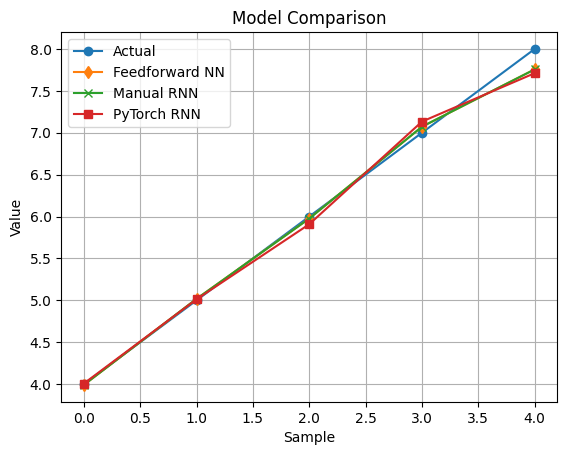

In [134]:
import matplotlib.pyplot as plt

# Convert to numpy
actual = y
pred_nn = predictions.squeeze().detach().numpy()        # Feedforward NN
pred_manual = predictions.squeeze().detach().numpy()    # Manual RNN (if overwritten, rename earlier)
pred_api = predictions_api.squeeze().detach().numpy()

plt.figure()

plt.plot(actual, marker='o', label="Actual")
plt.plot(pred_nn, marker='d', label="Feedforward NN")
plt.plot(pred_manual, marker='x', label="Manual RNN")
plt.plot(pred_api, marker='s', label="PyTorch RNN")

plt.title("Model Comparison")
plt.xlabel("Sample")
plt.ylabel("Value")

plt.legend()
plt.grid()

plt.show()

## 10. Limitations of RNN

RNNs introduce memory, but they are not perfect.

### Long-Term Dependency Problem

RNN struggles when important information is far in the past.

Example:
- Early input influences much later output
- Model forgets over time

**Think:** Can the model remember something from 50 steps ago?

### Vanishing Gradient (Intuition)

During training:
- Gradients shrink as they flow backward
- Earlier steps receive very little update

Result:
- Model forgets long-term dependencies